  0%|          | 0/5 [00:00<?, ?it/s]

Working on FFA/PPA 


  0%|          | 0/27 [00:00<?, ?it/s]

Working on dlPFC 


  0%|          | 0/27 [00:00<?, ?it/s]

...

  0%|          | 0/27 [00:00<?, ?it/s]

Working on lofc 


  0%|          | 0/27 [00:00<?, ?it/s]

Working on mofc 


  0%|          | 0/27 [00:00<?, ?it/s]

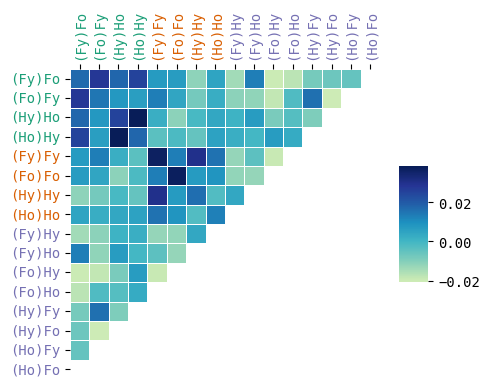

In [1]:
#Category_switching
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['FFA/PPA','dlPFC','hp','lofc','mofc']

subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])
categories2 =np.array(['(Fo)Hy', '(Fo)Ho', '(Fy)Hy', '(Fy)Ho', '(Ho)Fy', '(Ho)Fo', '(Hy)Fy', '(Hy)Fo'])

state_pairs = {
    '(Fy)Fo': ['(Fo)Hy', '(Fo)Ho'],
    '(Fo)Fy': ['(Fy)Hy', '(Fy)Ho'],
    '(Hy)Ho': ['(Ho)Fy', '(Ho)Fo'],
    '(Ho)Hy': ['(Hy)Fy', '(Hy)Fo']
}
index = pd.MultiIndex.from_product([mask_names,subject_inds,  categories2], names=['mask_name','subject', 'state2'])
df_score = pd.DataFrame(index=index, columns=['correlation','error_rate'])

average_all_subjects_rdm = np.zeros((len(subject_inds), 16, 16))
for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
        #print("The current subject is %s" % current_subject)
        data_dir = f'/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/'
        all_beta = f"{data_dir}/sub-{current_subject:02}_state.nii.gz"
        if current_subject == 21:
            all_beta = f"{data_dir}/sub-{current_subject:02}_state_nan.nii.gz"
        datasets = {"mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/mofc_bin.nii.gz"],
                    "lofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/lofc_bin.nii.gz"],
                    "hp":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/hp_bin.nii.gz"],
                    #"dlPFC":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/dlPfC_bin.nii.gz"],
                    "dlPFC":[f"/home/garlicseed/Mount/final/beta/dlpfc_bin2.nii.gz"],
                    "FFA/PPA":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/FFA-PPA_bin.nii.gz"],  
                    #"R_mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/R_mofc_bin.nii.gz"]
                   }
        labels = pd.read_csv('/home/garlicseed/Mount/final/beta/state_events.tsv',sep='\t')
        labels_run = labels['run']
        #categories = labels['state'].unique()
        session_labels = labels_run
        state_beta = nb.load(all_beta)

        mask_filename = datasets[mask_name][0]
        masker = NiftiMasker(
            mask_img=mask_filename,
            standardize="zscore_sample",
            runs=session_labels,
            smoothing_fwhm=4,
            t_r=1.5,
            memory="nilearn_cache",
            memory_level=1,
                 )
        fmri_masked = masker.fit_transform(state_beta)

        # 初始化相关矩阵和平均相关矩阵
        correlation_matrices = np.zeros((4, 3, 16, 16))
        average_correlation_matrices = np.zeros((4, 16, 16))

        # 对每个run进行循环
        for run in range(1, 5):
            # 初始化other_run的索引
            other_run_index = 0

            # 对每个other_run进行循环
            for other_run in range(1, 5):
                # 如果run和other_run不同
                if other_run != run:
                    # 获取当前run和other_run的beta map
                    mean_beta_maps = fmri_masked[(run-1)*16:run*16]
                    other_mean_beta_maps = fmri_masked[(other_run-1)*16:other_run*16]

                    # 计算当前run和other_run之间的相关矩阵
                    correlation_matrix = np.corrcoef(mean_beta_maps, other_mean_beta_maps)[16:, :16]

                    correlation_matrices[run-1, other_run_index] = correlation_matrix

                    # 更新other_run的索引
                    other_run_index += 1

            average_correlation_matrices[run-1] = np.nanmean(correlation_matrices[run-1], axis=0)

            subject_average_matrices = np.nanmean(average_correlation_matrices, axis=0)
            
            #subject_average_matrices[subject_average_matrices < 0] = np.nan

            average_all_subjects_rdm[i] = subject_average_matrices

            for state1, state2s in state_pairs.items():
                state1_index = np.where(categories == state1)[0][0]
                for state2 in state2s:
                    state2_index = np.where(categories == state2)[0][0]
                    df_score.loc[(mask_name, current_subject, state2), 'correlation'] = (subject_average_matrices[state1_index, state2_index] + subject_average_matrices[state2_index, state1_index]) / 2
            
            
            
            df1 = pd.read_table(f"/home/garlicseed/Mount/final/timeseries/sub-{current_subject:02}_rest_bold_1.txt")
            df1 = pd.DataFrame(df1)
            df1['dimA_shifted'] = df1.groupby('run')['dimA'].shift(1)
            df1['dimA_shifted'].fillna(df1.groupby('run')['dimA'].transform('first'), inplace=True)
            df1['state'] = '(' + df1['dimA_shifted'] + ')' + df1['dimA']
            
            for state2 in categories2:
                # 提取出该状态的所有行
                state_df = df1[df1['state'] == state2]

                # 当current_subject等于30时，只考虑run等于1，2，3的行
                #if current_subject == 30:
                    #state_df = state_df[state_df['run'].isin([1, 2, 3])]
                #if current_subject == 21:
                    #state_df = state_df[state_df['run'].isin([1, 3, 4])]    
                # 计算错误的次数（包括反应错误和反应错过）和总的反应次数
                #error_responses = ((state_df['error'] == 1)).sum()
                error_responses = ((state_df['error'] == 1) | (state_df['error'] == 2)).sum()
                total_responses = state_df['error'].count()

        
                # 计算错误率并保存到DataFrame中

        
                df_score.loc[(mask_name, current_subject, state2), 'error_rate'] = error_responses / total_responses if total_responses != 0 else np.nan   
    
    df_score.reset_index()
    df_score.to_csv(f'/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_SC_include_negative.tsv',sep='\t') 
    if mask_name == 'mofc':
        colorbar_colors = ['#FFFFDFFF', '#EDF8BFFF', '#C7E9B4FF', '#7FCDBBFF', 
          '#41B6C4FF', '#1D91C0FF', '#225EA8FF', '#253494FF', '#081D58FF']

        from matplotlib.colors import LinearSegmentedColormap

        # Create a custom linear colormap
        continuous_cmap = LinearSegmentedColormap.from_list("continuous", colorbar_colors)
        average_rdm = np.nanmean(average_all_subjects_rdm, axis=0)
        fig = plt.figure(figsize=(5, 5))  # 设置图片大小为10x8英寸
        ax = fig.add_subplot(111)
        cmap = sns.diverging_palette(230, 20, as_cmap=True)
        mask = np.tril(np.ones_like(average_rdm, dtype=bool))
        mask = np.fliplr(mask)
        categories_flip = np.flip(categories)
        sns.heatmap(average_rdm, mask=mask, cmap=continuous_cmap,cbar_kws={"shrink": .3, "aspect": 4.0},center = 0,
                    square=True, linewidths=.72 , xticklabels=categories, yticklabels=categories,ax=ax)

        ax.set_xticklabels(categories, rotation=90)
        ax.xaxis.tick_top()
        labels = ax.get_xmajorticklabels()
        for label in labels:
            text = label.get_text()
            if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
                label.set_color('#1B9E77')
            elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
                label.set_color('#D95F02')
            else:
                label.set_color('#7570B3')
        labels1 = ax.get_ymajorticklabels()
        for label1 in labels1:
            text = label1.get_text()
            if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
                label1.set_color('#1B9E77')
            elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
                label1.set_color('#D95F02')
            else:
                label1.set_color('#7570B3')
        plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/{mask_name}_SC_include_negative_figure3.svg", dpi=300, format="svg", bbox_inches='tight')
        plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/{mask_name}_SC_include_negative_figure3.png", dpi=300, format="png", bbox_inches='tight')
        plt.show()            

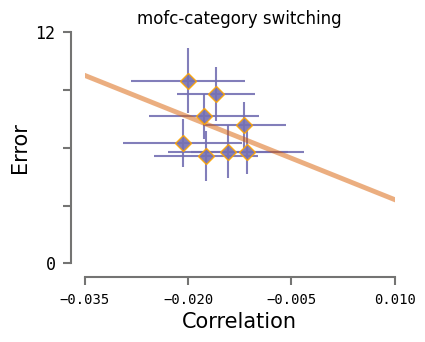

In [2]:
#plot mofc linear_correlation
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
GREY_DARK = "#747473"
mask_name = ['mofc']
df_score = pd.read_csv('/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_SC_include_negative.tsv',sep='\t')
df_score = df_score[df_score['mask_name'] == 'mofc']
df_score = df_score.drop(columns=['mask_name'])
df_mean = df_score.groupby('state2').mean()[['correlation', 'error_rate']]
df_sem = df_score.groupby('state2').sem()[['correlation', 'error_rate']]
# 创建一个新的DataFrame，包含平均值和标准误差
df2 = pd.concat([df_mean, df_sem], axis=1)
df2.columns = ['mean_correlation', 'mean_error_rate', 'sem_correlation', 'sem_error_rate']

# 对DataFrame进行排序，以便在图中正确显示状态
df2 = df2.sort_values(by='mean_correlation')

# 创建一个新的图形
plt.figure(figsize=(4, 3))

# 绘制每个状态的平均相关性和错误率，以及它们的标准误差
plt.errorbar(df2['mean_correlation'], df2['mean_error_rate'] * 100, xerr=df2['sem_correlation'],yerr=df2['sem_error_rate'] * 100, fmt='o',marker='D',color="#7570B3",markersize=8, markeredgecolor="orange",alpha=0.9, markeredgewidth=1)
#plt.errorbar(df['mean_correlation'], df['mean_error_rate'], xerr=df['sem_correlation'], yerr=df['sem_error_rate'], fmt='o')
df2['mean_error_rate'] = df2['mean_error_rate'].astype(float) * 100
df2['mean_correlation'] = df2['mean_correlation'].astype(float)
# 计算拟合直线的参数
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['mean_correlation'], df2['mean_error_rate'])
n = len(df2['mean_correlation'])  # 样本大小
t_value = r_value * np.sqrt((n-2) / (1 - r_value**2))
# 绘制拟合直线
#x = np.linspace(-0.045, df2['mean_correlation'].max(), 100)
x = np.linspace(-0.035, 0.01, 100)
y = slope * x + intercept
plt.plot(x, y, linewidth=3.5,color='#D95F02',alpha=0.5)
#sns.regplot(x=df2['mean_correlation'], y=df2['mean_error_rate'], line_kws={"color":"r","alpha":0.7,"lw":5})
# 设置图形的标题和坐标轴标签
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# 将x轴和y轴移动到数据坐标为0的位置
plt.gca().spines['bottom'].set_position(('data', 0))
plt.gca().spines['left'].set_position(('data', 0))

# 将x轴和y轴向外移动10个点，以使它们不会交叉在一起
plt.gca().spines['bottom'].set_position(('outward', 10))
plt.gca().spines['left'].set_position(('outward', 10))
# 添加刻度线
plt.gca().xaxis.set_ticks_position('bottom')
plt.gca().yaxis.set_ticks_position('left')

#plt.xlim(0, 0.03)
#plt.ylim(0, 10)


#plt.title('Correlation vs Error Rate for Different States')
plt.xlabel('Correlation',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.ylabel('Error',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.xlim(-0.035, 0.01)
plt.ylim(0, 12)
plt.xticks(np.arange(-0.035, 0.01, 0.015))
plt.yticks(np.arange(0, 12 + 3, 3))

# 只显示0和12以及0和0.025
#plt.gca().set_xticklabels([0 if np.isclose(loc, 0, atol=0.001) else 0.045 if np.isclose(loc, 0.045, atol=0.001) else '' for loc in plt.gca().get_xticks()],fontsize=12)
plt.gca().set_yticklabels([0 if np.isclose(loc, 0, atol=0.001) else 12 if np.isclose(loc, 12, atol=0.001) else '' for loc in plt.gca().get_yticks()],fontsize=12)
# 显示图形
ax = plt.gca()
ax.spines['left'].set_linewidth(1.5)
ax.spines["left"].set_color(GREY_DARK)
ax.tick_params(axis='y', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.tick_params(axis='x', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
plt.title('mofc-category switching', fontsize=12, fontdict={'family': 'DejaVu Sans'})
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/mofc_SC_include_negative_figure_corr.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/mofc_SC_include_negative_figure_corr.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

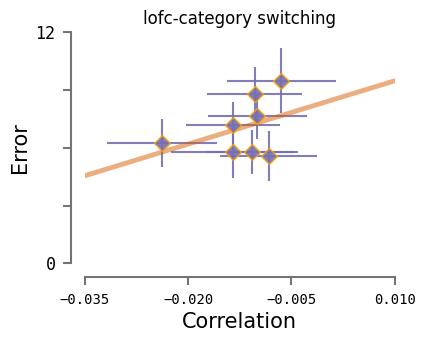

In [3]:
#plot lofc linear_correlation
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
GREY_DARK = "#747473"
mask_name = ['lofc']
df_score = pd.read_csv('/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_SC_include_negative.tsv',sep='\t')
df_score = df_score[df_score['mask_name'] == 'lofc']
df_score = df_score.drop(columns=['mask_name'])
df_mean = df_score.groupby('state2').mean()[['correlation', 'error_rate']]
df_sem = df_score.groupby('state2').sem()[['correlation', 'error_rate']]
# 创建一个新的DataFrame，包含平均值和标准误差
df2 = pd.concat([df_mean, df_sem], axis=1)
df2.columns = ['mean_correlation', 'mean_error_rate', 'sem_correlation', 'sem_error_rate']

# 对DataFrame进行排序，以便在图中正确显示状态
df2 = df2.sort_values(by='mean_correlation')

# 创建一个新的图形
plt.figure(figsize=(4, 3))

# 绘制每个状态的平均相关性和错误率，以及它们的标准误差
plt.errorbar(df2['mean_correlation'], df2['mean_error_rate'] * 100, xerr=df2['sem_correlation'],yerr=df2['sem_error_rate'] * 100, fmt='o',marker='D',color="#7570B3",markersize=8, markeredgecolor="orange",alpha=0.9, markeredgewidth=1)
#plt.errorbar(df['mean_correlation'], df['mean_error_rate'], xerr=df['sem_correlation'], yerr=df['sem_error_rate'], fmt='o')
df2['mean_error_rate'] = df2['mean_error_rate'].astype(float) * 100
df2['mean_correlation'] = df2['mean_correlation'].astype(float)
# 计算拟合直线的参数
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['mean_correlation'], df2['mean_error_rate'])
n = len(df2['mean_correlation'])  # 样本大小
t_value = r_value * np.sqrt((n-2) / (1 - r_value**2))
# 绘制拟合直线
#x = np.linspace(-0.045, df2['mean_correlation'].max(), 100)
x = np.linspace(-0.035, 0.01, 100)
y = slope * x + intercept
plt.plot(x, y, linewidth=3.5,color='#D95F02',alpha=0.5)
#sns.regplot(x=df2['mean_correlation'], y=df2['mean_error_rate'], line_kws={"color":"r","alpha":0.7,"lw":5})
# 设置图形的标题和坐标轴标签
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# 将x轴和y轴移动到数据坐标为0的位置
plt.gca().spines['bottom'].set_position(('data', 0))
plt.gca().spines['left'].set_position(('data', 0))

# 将x轴和y轴向外移动10个点，以使它们不会交叉在一起
plt.gca().spines['bottom'].set_position(('outward', 10))
plt.gca().spines['left'].set_position(('outward', 10))
# 添加刻度线
plt.gca().xaxis.set_ticks_position('bottom')
plt.gca().yaxis.set_ticks_position('left')

#plt.xlim(0, 0.03)
#plt.ylim(0, 10)


#plt.title('Correlation vs Error Rate for Different States')
plt.xlabel('Correlation',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.ylabel('Error',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.xlim(-0.035, 0.01)
plt.ylim(0, 12)
plt.xticks(np.arange(-0.035, 0.01, 0.015))
plt.yticks(np.arange(0, 12 + 3, 3))

# 只显示0和12以及0和0.025
#plt.gca().set_xticklabels([0 if np.isclose(loc, 0, atol=0.001) else 0.045 if np.isclose(loc, 0.045, atol=0.001) else '' for loc in plt.gca().get_xticks()],fontsize=12)
plt.gca().set_yticklabels([0 if np.isclose(loc, 0, atol=0.001) else 12 if np.isclose(loc, 12, atol=0.001) else '' for loc in plt.gca().get_yticks()],fontsize=12)
# 显示图形
ax = plt.gca()
ax.spines['left'].set_linewidth(1.5)
ax.spines["left"].set_color(GREY_DARK)
ax.tick_params(axis='y', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.tick_params(axis='x', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
plt.title('lofc-category switching', fontsize=12, fontdict={'family': 'DejaVu Sans'})
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/lofc_SC_include_negative_figure_corr.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/lofc_SC_include_negative_figure_corr.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

In [4]:
#Age_Switching
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['FFA/PPA','dlPFC','hp','lofc','mofc']

subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])
categories2 =np.array(['(Fo)Fy', '(Fy)Fo', '(Ho)Hy', '(Hy)Ho', '(Fo)Hy', '(Fy)Ho', '(Ho)Fy', '(Hy)Fo'])

state_pairs = {
    '(Fo)Fo': ['(Fo)Fy'],
    '(Fy)Fy': ['(Fy)Fo'],
    '(Ho)Ho': ['(Ho)Hy'],
    '(Hy)Hy': ['(Hy)Ho'],
    '(Fy)Fo': ['(Fo)Hy'],
    '(Fo)Fy': ['(Fy)Ho'],
    '(Hy)Ho': ['(Ho)Fy'],
    '(Ho)Hy': ['(Hy)Fo'],
}
index = pd.MultiIndex.from_product([mask_names, subject_inds,  categories2], names=['mask_name','subject', 'state2'])
df_score = pd.DataFrame(index=index, columns=['correlation','error_rate'])

average_all_subjects_rdm = np.zeros((len(subject_inds), 16, 16))
for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
        #print("The current subject is %s" % current_subject)
        data_dir = f'/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/'
        all_beta = f"{data_dir}/sub-{current_subject:02}_state.nii.gz"
        if current_subject == 21:
            all_beta = f"{data_dir}/sub-{current_subject:02}_state_nan.nii.gz"
        datasets = {"mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/mofc_bin.nii.gz"],
                    "lofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/lofc_bin.nii.gz"],
                    "hp":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/hp_bin.nii.gz"],
                    #"dlPFC":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/dlPfC_bin.nii.gz"],
                    "dlPFC":[f"/home/garlicseed/Mount/final/beta/dlpfc_bin2.nii.gz"],
                    "FFA/PPA":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/FFA-PPA_bin.nii.gz"],  
                    #"R_mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/R_mofc_bin.nii.gz"]
                   }
        labels = pd.read_csv('/home/garlicseed/Mount/final/beta/state_events.tsv',sep='\t')
        labels_run = labels['run']
        #categories = labels['state'].unique()
        session_labels = labels_run
        state_beta = nb.load(all_beta)

        mask_filename = datasets[mask_name][0]
        masker = NiftiMasker(
            mask_img=mask_filename,
            standardize="zscore_sample",
            runs=session_labels,
            smoothing_fwhm=4,
            t_r=1.5,
            memory="nilearn_cache",
            memory_level=1,
                 )
        fmri_masked = masker.fit_transform(state_beta)

        # 初始化相关矩阵和平均相关矩阵
        correlation_matrices = np.zeros((4, 3, 16, 16))
        average_correlation_matrices = np.zeros((4, 16, 16))

        # 对每个run进行循环
        for run in range(1, 5):
            # 初始化other_run的索引
            other_run_index = 0

            # 对每个other_run进行循环
            for other_run in range(1, 5):
                # 如果run和other_run不同
                if other_run != run:
                    # 获取当前run和other_run的beta map
                    mean_beta_maps = fmri_masked[(run-1)*16:run*16]
                    other_mean_beta_maps = fmri_masked[(other_run-1)*16:other_run*16]

                    # 计算当前run和other_run之间的相关矩阵
                    correlation_matrix = np.corrcoef(mean_beta_maps, other_mean_beta_maps)[16:, :16]

                    correlation_matrices[run-1, other_run_index] = correlation_matrix

                    # 更新other_run的索引
                    other_run_index += 1

            average_correlation_matrices[run-1] = np.nanmean(correlation_matrices[run-1], axis=0)

            subject_average_matrices = np.nanmean(average_correlation_matrices, axis=0)
            
            #subject_average_matrices[subject_average_matrices < 0] = np.nan

            average_all_subjects_rdm[i] = subject_average_matrices

            for state1, state2s in state_pairs.items():
                state1_index = np.where(categories == state1)[0][0]
                for state2 in state2s:
                    state2_index = np.where(categories == state2)[0][0]
                    df_score.loc[(mask_name, current_subject, state2), 'correlation'] = subject_average_matrices[state1_index, state2_index]
            
            
            
            df1 = pd.read_table(f"/home/garlicseed/Mount/final/timeseries/sub-{current_subject:02}_rest_bold_1.txt")
            df1 = pd.DataFrame(df1)
            df1['dimA_shifted'] = df1.groupby('run')['dimA'].shift(1)
            df1['dimA_shifted'].fillna(df1.groupby('run')['dimA'].transform('first'), inplace=True)
            df1['state'] = '(' + df1['dimA_shifted'] + ')' + df1['dimA']
            
            for state2 in categories2:
                # 提取出该状态的所有行
                state_df = df1[df1['state'] == state2]

                # 当current_subject等于30时，只考虑run等于1，2，3的行
                #if current_subject == 30:
                    #state_df = state_df[state_df['run'].isin([1, 2, 3])]
                #if current_subject == 21:
                    #state_df = state_df[state_df['run'].isin([1, 3, 4])]    
                # 计算错误的次数（包括反应错误和反应错过）和总的反应次数
                #error_responses = ((state_df['error'] == 1)).sum()
                error_responses = ((state_df['error'] == 1) | (state_df['error'] == 2)).sum()
                total_responses = state_df['error'].count()

        
                # 计算错误率并保存到DataFrame中

        
                df_score.loc[(mask_name, current_subject, state2), 'error_rate'] = error_responses / total_responses if total_responses != 0 else np.nan   
    df_score.reset_index()
    df_score.to_csv('/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_AC_include_negative.tsv',sep='\t') 
    df_score.to_csv('/home/garlicseed/Mount/final/RSA/state_representation/Sorces/correlation_error_AC_include_negative.tsv',sep='\t')
                    

  0%|          | 0/5 [00:00<?, ?it/s]

Working on FFA/PPA 


  0%|          | 0/27 [00:00<?, ?it/s]

Working on dlPFC 


  0%|          | 0/27 [00:00<?, ?it/s]

...

  0%|          | 0/27 [00:00<?, ?it/s]

Working on lofc 


  0%|          | 0/27 [00:00<?, ?it/s]

Working on mofc 


  0%|          | 0/27 [00:00<?, ?it/s]

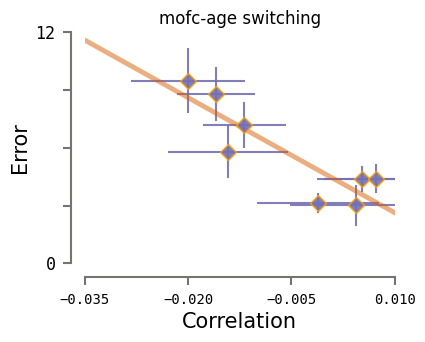

In [5]:
#plot mofc linear_correlation
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
GREY_DARK = "#747473"
mask_name = ['mofc']
df_score = pd.read_csv('/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_AC_include_negative.tsv',sep='\t')
df_score = df_score[df_score['mask_name'] == 'mofc']
df_score = df_score.drop(columns=['mask_name'])
df_mean = df_score.groupby('state2').mean()[['correlation', 'error_rate']]
df_sem = df_score.groupby('state2').sem()[['correlation', 'error_rate']]
# 创建一个新的DataFrame，包含平均值和标准误差
df2 = pd.concat([df_mean, df_sem], axis=1)
df2.columns = ['mean_correlation', 'mean_error_rate', 'sem_correlation', 'sem_error_rate']

# 对DataFrame进行排序，以便在图中正确显示状态
df2 = df2.sort_values(by='mean_correlation')

# 创建一个新的图形
plt.figure(figsize=(4, 3))

# 绘制每个状态的平均相关性和错误率，以及它们的标准误差
plt.errorbar(df2['mean_correlation'], df2['mean_error_rate'] * 100, xerr=df2['sem_correlation'],yerr=df2['sem_error_rate'] * 100, fmt='o',marker='D',color="#7570B3",markersize=8, markeredgecolor="orange",alpha=0.9, markeredgewidth=1)
#plt.errorbar(df['mean_correlation'], df['mean_error_rate'], xerr=df['sem_correlation'], yerr=df['sem_error_rate'], fmt='o')
df2['mean_error_rate'] = df2['mean_error_rate'].astype(float) * 100
df2['mean_correlation'] = df2['mean_correlation'].astype(float)
# 计算拟合直线的参数
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['mean_correlation'], df2['mean_error_rate'])
n = len(df2['mean_correlation'])  # 样本大小
t_value = r_value * np.sqrt((n-2) / (1 - r_value**2))
# 绘制拟合直线
#x = np.linspace(-0.045, df2['mean_correlation'].max(), 100)
x = np.linspace(-0.035, 0.01, 100)
y = slope * x + intercept
plt.plot(x, y, linewidth=3.5,color='#D95F02',alpha=0.5)
#sns.regplot(x=df2['mean_correlation'], y=df2['mean_error_rate'], line_kws={"color":"r","alpha":0.7,"lw":5})
# 设置图形的标题和坐标轴标签
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# 将x轴和y轴移动到数据坐标为0的位置
plt.gca().spines['bottom'].set_position(('data', 0))
plt.gca().spines['left'].set_position(('data', 0))

# 将x轴和y轴向外移动10个点，以使它们不会交叉在一起
plt.gca().spines['bottom'].set_position(('outward', 10))
plt.gca().spines['left'].set_position(('outward', 10))
# 添加刻度线
plt.gca().xaxis.set_ticks_position('bottom')
plt.gca().yaxis.set_ticks_position('left')

#plt.xlim(0, 0.03)
#plt.ylim(0, 10)


#plt.title('Correlation vs Error Rate for Different States')
plt.xlabel('Correlation',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.ylabel('Error',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.xlim(-0.035, 0.01)
plt.ylim(0, 12)
plt.xticks(np.arange(-0.035, 0.01, 0.015))
plt.yticks(np.arange(0, 12 + 3, 3))

# 只显示0和12以及0和0.025
#plt.gca().set_xticklabels([0 if np.isclose(loc, 0, atol=0.001) else 0.045 if np.isclose(loc, 0.045, atol=0.001) else '' for loc in plt.gca().get_xticks()],fontsize=12)
plt.gca().set_yticklabels([0 if np.isclose(loc, 0, atol=0.001) else 12 if np.isclose(loc, 12, atol=0.001) else '' for loc in plt.gca().get_yticks()],fontsize=12)
# 显示图形
ax = plt.gca()
ax.spines['left'].set_linewidth(1.5)
ax.spines["left"].set_color(GREY_DARK)
ax.tick_params(axis='y', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.tick_params(axis='x', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
plt.title('mofc-age switching', fontsize=12, fontdict={'family': 'DejaVu Sans'})
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/mofc_AC_include_negative_figure_corr.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/mofc_AC_include_negative_figure_corr.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

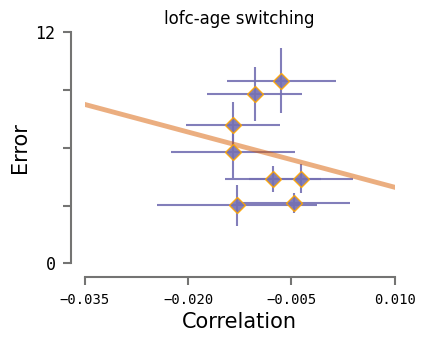

In [6]:
#plot mofc linear_correlation
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
GREY_DARK = "#747473"
mask_name = ['lofc']
df_score = pd.read_csv('/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_AC_include_negative.tsv',sep='\t')
df_score = df_score[df_score['mask_name'] == 'lofc']
df_score = df_score.drop(columns=['mask_name'])
df_mean = df_score.groupby('state2').mean()[['correlation', 'error_rate']]
df_sem = df_score.groupby('state2').sem()[['correlation', 'error_rate']]
# 创建一个新的DataFrame，包含平均值和标准误差
df2 = pd.concat([df_mean, df_sem], axis=1)
df2.columns = ['mean_correlation', 'mean_error_rate', 'sem_correlation', 'sem_error_rate']

# 对DataFrame进行排序，以便在图中正确显示状态
df2 = df2.sort_values(by='mean_correlation')

# 创建一个新的图形
plt.figure(figsize=(4, 3))

# 绘制每个状态的平均相关性和错误率，以及它们的标准误差
plt.errorbar(df2['mean_correlation'], df2['mean_error_rate'] * 100, xerr=df2['sem_correlation'],yerr=df2['sem_error_rate'] * 100, fmt='o',marker='D',color="#7570B3",markersize=8, markeredgecolor="orange",alpha=0.9, markeredgewidth=1)
#plt.errorbar(df['mean_correlation'], df['mean_error_rate'], xerr=df['sem_correlation'], yerr=df['sem_error_rate'], fmt='o')
df2['mean_error_rate'] = df2['mean_error_rate'].astype(float) * 100
df2['mean_correlation'] = df2['mean_correlation'].astype(float)
# 计算拟合直线的参数
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['mean_correlation'], df2['mean_error_rate'])
n = len(df2['mean_correlation'])  # 样本大小
t_value = r_value * np.sqrt((n-2) / (1 - r_value**2))
# 绘制拟合直线
#x = np.linspace(-0.045, df2['mean_correlation'].max(), 100)
x = np.linspace(-0.035, 0.01, 100)
y = slope * x + intercept
plt.plot(x, y, linewidth=3.5,color='#D95F02',alpha=0.5)
#sns.regplot(x=df2['mean_correlation'], y=df2['mean_error_rate'], line_kws={"color":"r","alpha":0.7,"lw":5})
# 设置图形的标题和坐标轴标签
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# 将x轴和y轴移动到数据坐标为0的位置
plt.gca().spines['bottom'].set_position(('data', 0))
plt.gca().spines['left'].set_position(('data', 0))

# 将x轴和y轴向外移动10个点，以使它们不会交叉在一起
plt.gca().spines['bottom'].set_position(('outward', 10))
plt.gca().spines['left'].set_position(('outward', 10))
# 添加刻度线
plt.gca().xaxis.set_ticks_position('bottom')
plt.gca().yaxis.set_ticks_position('left')

#plt.xlim(0, 0.03)
#plt.ylim(0, 10)


#plt.title('Correlation vs Error Rate for Different States')
plt.xlabel('Correlation',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.ylabel('Error',fontsize=15, fontdict={'family': 'DejaVu Sans'})
plt.xlim(-0.035, 0.01)
plt.ylim(0, 12)
plt.xticks(np.arange(-0.035, 0.01, 0.015))
plt.yticks(np.arange(0, 12 + 3, 3))

# 只显示0和12以及0和0.025
#plt.gca().set_xticklabels([0 if np.isclose(loc, 0, atol=0.001) else 0.045 if np.isclose(loc, 0.045, atol=0.001) else '' for loc in plt.gca().get_xticks()],fontsize=12)
plt.gca().set_yticklabels([0 if np.isclose(loc, 0, atol=0.001) else 12 if np.isclose(loc, 12, atol=0.001) else '' for loc in plt.gca().get_yticks()],fontsize=12)
# 显示图形
ax = plt.gca()
ax.spines['left'].set_linewidth(1.5)
ax.spines["left"].set_color(GREY_DARK)
ax.tick_params(axis='y', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.tick_params(axis='x', direction='out', length=6, width=1.5, pad=5,color = GREY_DARK)
plt.title('lofc-age switching', fontsize=12, fontdict={'family': 'DejaVu Sans'})
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/lofc_AC_include_negative_figure_corr.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig(f"/media/garlicseed/data/final/RSA/state_representation/Figures/lofc_AC_include_negative_figure_corr.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

In [10]:
#save stats_data
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
conditions = ['SC']
mask_names = ['FFA/PPA','dlPFC','hp','lofc','mofc']

for condition in conditions:
    df_scores = pd.read_csv(f'/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_{condition}_include_negative.tsv',sep='\t')
    results = pd.DataFrame(columns=['mask_name', 't_value', 'r_value', 'p_value'])
    for mask_name in mask_names:
        y_data = df_scores[(df_scores["mask_name"] == mask_name)][['state2','correlation','error_rate']]
        df_mean = y_data.groupby('state2').mean()[['correlation', 'error_rate']]
        df_sem = y_data.groupby('state2').sem()[['correlation', 'error_rate']]
        # 创建一个新的DataFrame，包含平均值和标准误差
        df2 = pd.concat([df_mean, df_sem], axis=1)
        df2.columns = ['mean_correlation', 'mean_error_rate', 'sem_correlation', 'sem_error_rate']

        # 对DataFrame进行排序，以便在图中正确显示状态
        df2 = df2.sort_values(by='mean_correlation')
        df2['mean_error_rate'] = df2['mean_error_rate'].astype(float) * 100
        df2['mean_correlation'] = df2['mean_correlation'].astype(float)
        slope, intercept, r_value, p_value, std_err = stats.linregress(df2['mean_correlation'], df2['mean_error_rate'])
        n = len(df2['mean_correlation'])  # 样本大小
        t_value = r_value * np.sqrt((n-2) / (1 - r_value**2))
        results = results._append({'mask_name': mask_name, 't_value': t_value, 'r_value': r_value, 'p_value': p_value}, ignore_index=True)

    # 将结果保存到CSV文件中
results.to_csv(f'/media/garlicseed/data/final/RSA/state_representation/Sorces/{condition}_include_negative_stats.txt', index=False)

In [11]:
results

,mask_name,t_value,r_value,p_value
0,FFA/PPA,0.264592,0.107394,0.800178
1,dlPFC,-0.388993,-0.156840,0.710711
2,hp,1.038288,0.390266,0.339156
3,lofc,1.045022,0.392409,0.336275
4,mofc,-0.879920,-0.338075,0.412754


In [8]:
#save stats_data
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
conditions = ['AC']
mask_names = ['FFA/PPA','dlPFC','hp','lofc','mofc']

for condition in conditions:
    df_scores = pd.read_csv(f'/media/garlicseed/data/final/RSA/state_representation/Sorces/correlation_error_{condition}_include_negative.tsv',sep='\t')
    results = pd.DataFrame(columns=['mask_name', 't_value', 'r_value', 'p_value'])
    for mask_name in mask_names:
        y_data = df_scores[(df_scores["mask_name"] == mask_name)][['state2','correlation','error_rate']]
        df_mean = y_data.groupby('state2').mean()[['correlation', 'error_rate']]
        df_sem = y_data.groupby('state2').sem()[['correlation', 'error_rate']]
        # 创建一个新的DataFrame，包含平均值和标准误差
        df2 = pd.concat([df_mean, df_sem], axis=1)
        df2.columns = ['mean_correlation', 'mean_error_rate', 'sem_correlation', 'sem_error_rate']

        # 对DataFrame进行排序，以便在图中正确显示状态
        df2 = df2.sort_values(by='mean_correlation')
        df2['mean_error_rate'] = df2['mean_error_rate'].astype(float) * 100
        df2['mean_correlation'] = df2['mean_correlation'].astype(float)
        slope, intercept, r_value, p_value, std_err = stats.linregress(df2['mean_correlation'], df2['mean_error_rate'])
        n = len(df2['mean_correlation'])  # 样本大小
        t_value = r_value * np.sqrt((n-2) / (1 - r_value**2))
        results = results._append({'mask_name': mask_name, 't_value': t_value, 'r_value': r_value, 'p_value': p_value}, ignore_index=True)

    # 将结果保存到CSV文件中
results.to_csv(f'/media/garlicseed/data/final/RSA/state_representation/Sorces/{condition}_include_negative_stats.txt', index=False)

In [9]:
results

,mask_name,t_value,r_value,p_value
0,FFA/PPA,-0.128897,-0.052549,0.901651
1,dlPFC,-1.356533,-0.484470,0.223748
2,hp,-2.366940,-0.694886,0.055753
3,lofc,-0.382361,-0.154231,0.715371
4,mofc,-4.392542,-0.873381,0.004605
